In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/priyankabarik/liver-diseases/Testing_Liver_Disease_Dataset.csv
/kaggle/input/datasets/priyankabarik/liver-diseases/Training_Liver_Disease_Dataset.csv


In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/priyankabarik/liver-diseases/Training_Liver_Disease_Dataset.csv")
test_df = pd.read_csv("/kaggle/input/datasets/priyankabarik/liver-diseases/Testing_Liver_Disease_Dataset.csv")
train_df.head()

,Age,Gender,Occupation,BMI,Obesity_Class,Waist_Circumference,Diet_Quality,Physical_Activity,Sleep_Hours,Smoking_Status,...,Bilirubin,Albumin,Platelets,Alk_Phosphatase,GGT,Triglycerides,INR,Medication_History,Source,Liver_Disease_Class
0,62,Female,Healthcare Worker,29.5,Overweight,89.6,Poor,Sedentary,6.6,Former,...,0.69,3.78,190,79,10,155,0.80,Steroids,Johns Hopkins Hospital,Healthy Liver
1,39,Female,Farmer,26.7,Overweight,101.9,Poor,Low,7.0,Current,...,1.07,4.38,196,143,13,276,1.14,Diabetes Medication,Cleveland Clinic,Fatty Liver Disease (NAFLD)
2,45,Male,Student,25.5,Overweight,74.5,Poor,Low,6.7,Former,...,2.55,3.64,311,84,143,145,1.10,Steroids,KGMU,Alcoholic Liver Disease
3,67,Male,Office Worker,30.8,Obesity I,98.2,Average,Sedentary,8.5,Current,...,1.89,3.58,307,92,30,91,1.20,Hepatotoxic Drugs,KGMU,Alcoholic Liver Disease
4,18,Female,Farmer,27.2,Overweight,96.9,Average,Sedentary,7.4,Former,...,0.73,4.63,374,73,10,162,1.20,NaN,Mount Sinai Hospital,Healthy Liver


In [3]:
print(train_df.shape)
print(train_df.info())

(30000, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     30000 non-null  int64  
 1   Gender                  30000 non-null  object 
 2   Occupation              30000 non-null  object 
 3   BMI                     30000 non-null  float64
 4   Obesity_Class           30000 non-null  object 
 5   Waist_Circumference     30000 non-null  float64
 6   Diet_Quality            30000 non-null  object 
 7   Physical_Activity       30000 non-null  object 
 8   Sleep_Hours             30000 non-null  float64
 9   Smoking_Status          30000 non-null  object 
 10  Alcohol_Consumption     22522 non-null  object 
 11  Sym_Fatigue             30000 non-null  int64  
 12  Sym_Jaundice            30000 non-null  int64  
 13  Sym_Abdominal_Pain      30000 non-null  int64  
 14  Sym_Itching             30

In [4]:
print(train_df['Liver_Disease_Class'].value_counts())

Liver_Disease_Class
Healthy Liver                     13500
Fatty Liver Disease (NAFLD)        9000
Alcoholic Liver Disease            3000
General Liver Disease Severity     2400
Liver Cirrhosis Risk               2100
Name: count, dtype: int64


In [5]:
label_encoders = {}

for col in train_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    label_encoders[col] = le

In [6]:
print(label_encoders.keys())

dict_keys(['Gender', 'Occupation', 'Obesity_Class', 'Diet_Quality', 'Physical_Activity', 'Smoking_Status', 'Alcohol_Consumption', 'Medication_History', 'Source', 'Liver_Disease_Class'])


In [7]:
mapping = dict(zip(label_encoders['Liver_Disease_Class'].classes_, 
                   range(len(label_encoders['Liver_Disease_Class'].classes_))))
print(mapping)

{'Alcoholic Liver Disease': 0, 'Fatty Liver Disease (NAFLD)': 1, 'General Liver Disease Severity': 2, 'Healthy Liver': 3, 'Liver Cirrhosis Risk': 4}


In [8]:
X_train = train_df.drop(columns=['Liver_Disease_Class'])
y_train = train_df['Liver_Disease_Class']

X_test = test_df.drop(columns=['Liver_Disease_Class'])
y_test = test_df['Liver_Disease_Class']



###  Entropy Formula

The entropy of a dataset is:

$$
H(S) = - \sum_{i=1}^{n} p_i \log_2(p_i)
$$

Where:
- $p_i$ = probability of class $i$  
- $n$ = total number of classes  



Information Gain is calculated as the reduction in entropy after a split:

$$
IG(S, X) = H(S) - \sum_{j} \frac{n_j}{n} H(S_j)
$$

Where:
- $H(S)$ = entropy of parent node  
- $H(S_j)$ = entropy of child node $j$  
- $n_j$ = number of samples in child node $j$  
- $n$ = total number of samples  


In [9]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [10]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8798181818181818
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       550
           1       0.83      0.86      0.85      1650
           2       0.82      0.72      0.77       440
           3       0.92      0.93      0.92      2475
           4       0.99      0.99      0.99       385

    accuracy                           0.88      5500
   macro avg       0.88      0.85      0.86      5500
weighted avg       0.88      0.88      0.88      5500



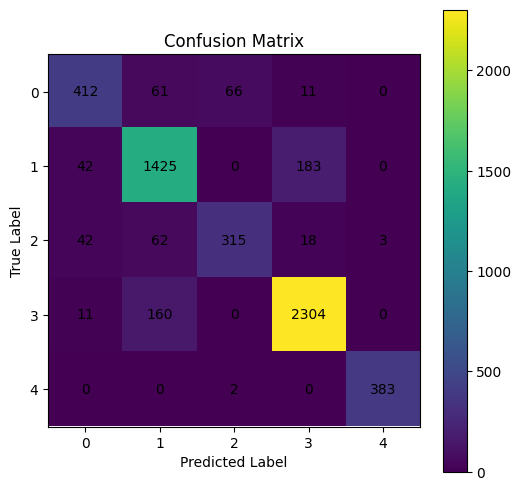

In [11]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

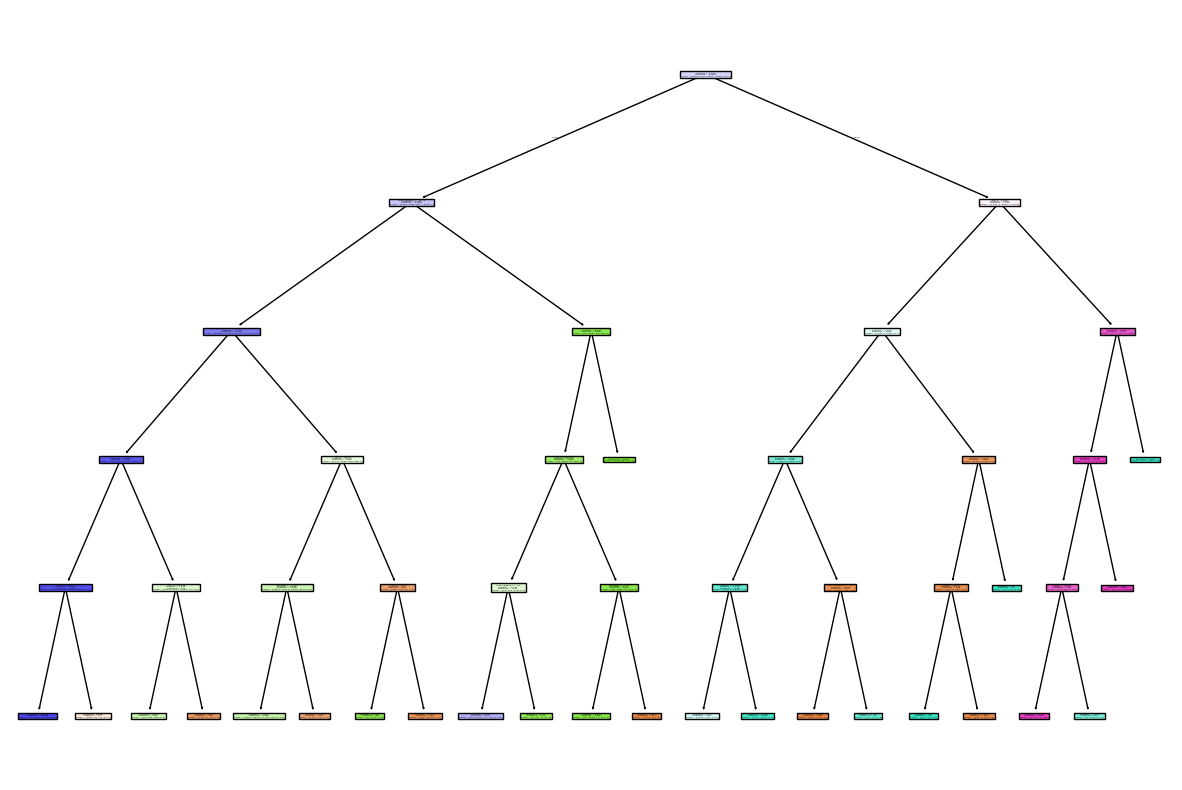

In [12]:
plt.figure(figsize=(15,10))
plot_tree(model, feature_names=X_train.columns, filled=True)
plt.show()

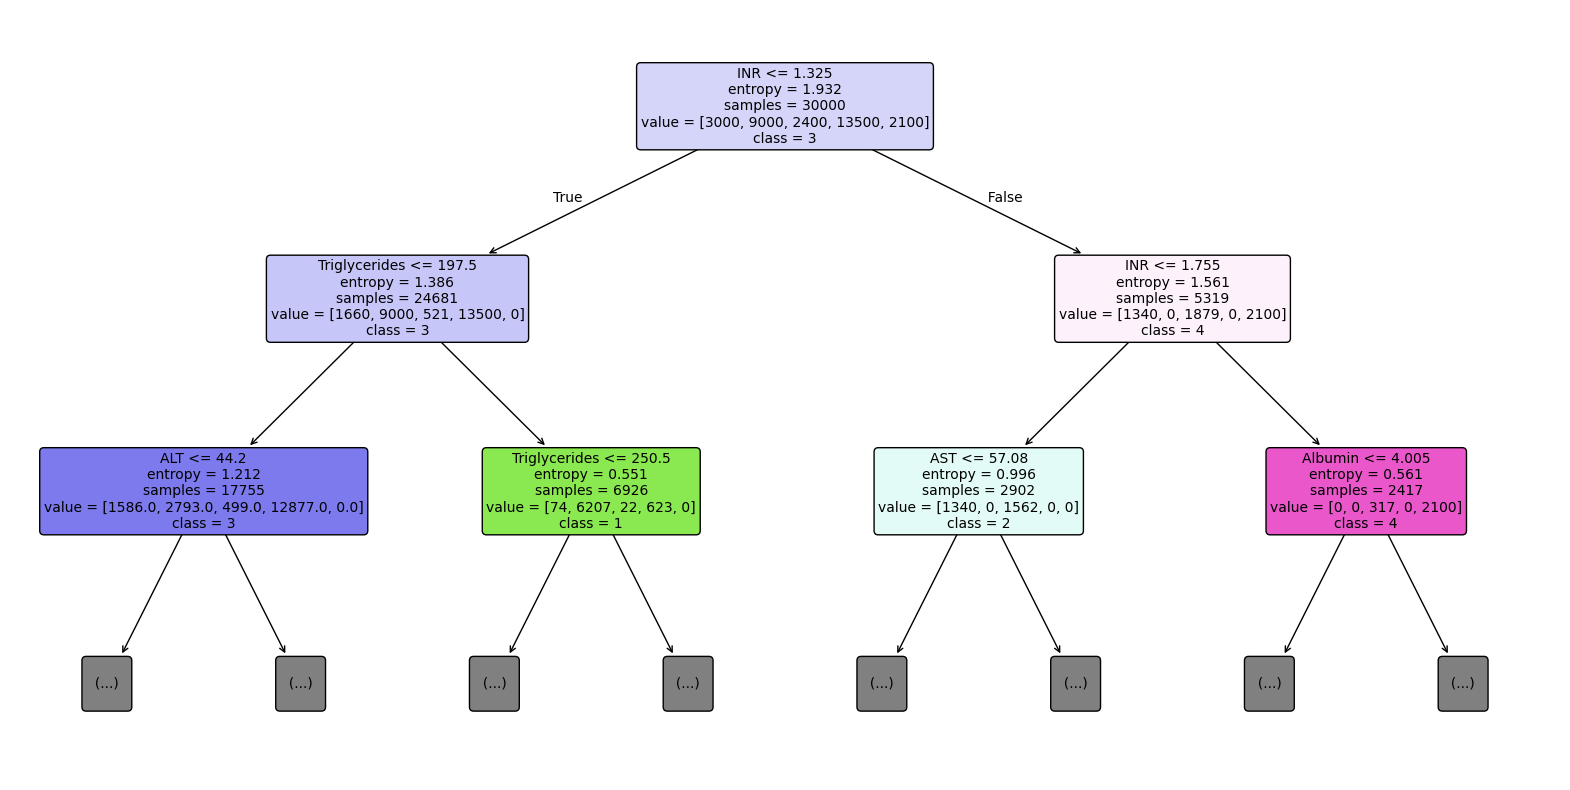

In [13]:
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X_train.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=2
)
plt.show()

The decision tree first splits on INR, indicating it is the most significant feature. Subsequent splits on triglycerides, ALT, AST, and albumin refine the classification into different liver disease types based on severity and metabolic indicators.

In [14]:
class_counts = train_df['Liver_Disease_Class'].value_counts()

print(class_counts)

Liver_Disease_Class
3    13500
1     9000
0     3000
2     2400
4     2100
Name: count, dtype: int64


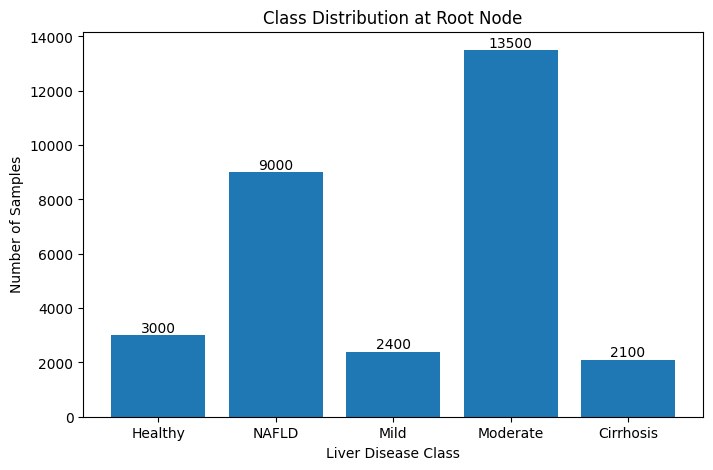

In [15]:
counts = [3000, 9000, 2400, 13500, 2100]
class_labels = ['Healthy', 'NAFLD', 'Mild', 'Moderate', 'Cirrhosis']
classes = class_labels

plt.figure(figsize=(8,5))

bars = plt.bar(classes, counts)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.title("Class Distribution at Root Node")
plt.xlabel("Liver Disease Class")
plt.ylabel("Number of Samples")

plt.show()

###  Class Distribution at Root Node

From the decision tree:

- Total samples = 30000  
- Class distribution:

$$
[3000,\ 9000,\ 2400,\ 13500,\ 2100]
$$

---

### Calculate Probabilities

$$
p_1 = \frac{3000}{30000}, \quad
p_2 = \frac{9000}{30000}, \quad
p_3 = \frac{2400}{30000}, \quad
p_4 = \frac{13500}{30000}, \quad
p_5 = \frac{2100}{30000}
$$

---

### Apply Entropy Formula

$$
H(S) = - \Big(
p_1 \log_2(p_1) +
p_2 \log_2(p_2) +
p_3 \log_2(p_3) +
p_4 \log_2(p_4) +
p_5 \log_2(p_5)
\Big)
$$

---

# ENTROPY OF DATASET

$$
 H(S) \approx 1.934
$$

---

##  Information Gain Calculation for INR

### Entropy of Parent Node

$$
H(\text{parent}) \approx 1.934
$$

---

### Split Dataset Using INR

From the decision tree:

- INR $\leq 1.325$ → Left node  
- INR $> 1.325$ → Right node  

The dataset is divided into:

- Left subset ($n_1$ samples)  
- Right subset ($n_2$ samples)  

---

### Class Distribution After Split

After splitting using INR:

**Left node (INR $\leq 1.325$):**

$$
[1660,\ 9000,\ 521,\ 13500,\ 0]
$$

**Right node (INR $> 1.325$):**

$$
[1340,\ 0,\ 1879,\ 0,\ 2100]
$$

These distributions are more pure compared to the root node, indicating better class separation after the split

---
###  Compute Entropy of Each Subset

$$
H(\text{left}) = - \sum p_i \log_2(p_i)
$$

$$
H(\text{right}) = - \sum p_i \log_2(p_i)
$$

---

### Compute Weighted Average Entropy

$$
H(\text{children}) =
\frac{n_1}{n} H(\text{left}) +
\frac{n_2}{n} H(\text{right})
$$

---

### Calculate Information Gain

$$
IG(\text{INR}) =
H(\text{parent}) - H(\text{children})
$$

---




### Given Data

Left node:

$$
[1660,\ 9000,\ 521,\ 13500,\ 0], \quad n_1 = 24681
$$

Right node:

$$
[1340,\ 0,\ 1879,\ 0,\ 2100], \quad n_2 = 5319
$$

Total samples:

$$
n = 30000
$$

---

### Entropy of Left Node

$$
p_1 = \frac{1660}{24681}, \quad
p_2 = \frac{9000}{24681}, \quad
p_3 = \frac{521}{24681}, \quad
p_4 = \frac{13500}{24681}, \quad
p_5 = 0
$$

$$
H(\text{left}) = - \sum p_i \log_2(p_i) \approx 1.39
$$

---

### Entropy of Right Node

$$
p_1 = \frac{1340}{5319}, \quad
p_2 = 0, \quad
p_3 = \frac{1879}{5319}, \quad
p_4 = 0, \quad
p_5 = \frac{2100}{5319}
$$

$$
H(\text{right}) = - \sum p_i \log_2(p_i) \approx 1.56
$$

---

### Weighted Average Entropy

$$
H(\text{children}) =
\frac{24681}{30000} \cdot 1.39 +
\frac{5319}{30000} \cdot 1.56
$$

$$
H(\text{children}) \approx 1.42
$$

---

### Information Gain

$$
H(\text{parent}) \approx 1.93
$$

$$
IG(\text{INR}) =
H(\text{parent}) - H(\text{children})
$$

$$
IG(\text{INR}) = 1.93 - 1.42 \approx 0.51
$$

---

### 🔹 Conclusion

The INR feature provides a significant reduction in entropy, resulting in high information gain. Therefore, it is selected as the root node of the decision tree.

### Priting Mutual INFO
Similar to IG higher value represents better info gain

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif

ig = mutual_info_classif(X_train, y_train)

for feature, score in zip(X_train.columns, ig):
    print(feature, ":", score)

Age : 0.00442596777240345
Gender : 0.0022437505260310964
Occupation : 0.002448205354754318
BMI : 0.0
Obesity_Class : 0.0008387085870045219
Waist_Circumference : 0.004766057470850349
Diet_Quality : 0.0035003872248617895
Physical_Activity : 0.0
Sleep_Hours : 0.0
Smoking_Status : 0.0
Alcohol_Consumption : 0.0
Sym_Fatigue : 0.15313192425061084
Sym_Jaundice : 0.08013898506773964
Sym_Abdominal_Pain : 0.05668507397185296
Sym_Itching : 0.05738658424254783
Sym_Ascites : 0.06803021668323606
Sym_Dark_Urine : 0.09624494944179762
Sym_Weight_Loss : 0.010842408372654155
Comorb_Diabetes : 0.04135539714930303
Comorb_Hypertension : 0.002526268479835281
Comorb_Genetic_History : 0.029051275728758874
ALT : 0.3249595283660158
AST : 0.39187434050870373
Bilirubin : 0.32414037353184644
Albumin : 0.2636863853071669
Platelets : 0.1280280721089886
Alk_Phosphatase : 0.0
GGT : 0.3600569598517398
Triglycerides : 0.3261865529926278
INR : 0.7204678891665546
Medication_History : 0.0
Source : 0.006778126247990457


###  Gini Impurity

The Gini Impurity of a dataset is defined as:

$$
Gini(S) = 1 - \sum_{i=1}^{n} p_i^2
$$

Where:
- $p_i$ = probability of class $i$  
- $n$ = number of classes  
